# 06 · ML algorithms exploration (Issue #11)

```
03 clean ─► 04 feature engineering ─► 05 encode & scale ─► 06 algorithm exploration ─► #12 candidate models ─► #13 build ─► #14 tune
                                        model_ready_*.parquet      ← this notebook
```

**Goal:** before picking and tuning models, see how each **family** of classification algorithm behaves on our data, then hand a
short, evidence-based list to Issue #12 (Candidate Models Identification).

**Ground rules, so the comparison is fair:**
- **Same inputs for every model**: `model_ready_{fit,valid}.parquet` from notebook 05 (106 columns: imputed, scaled, one-hot).
- **Same out-of-time split**: train on weeks 0–79 (`fit`), score on weeks 80–91 (`valid`). The test file is not touched.
- **Near-default settings**: tuning is Issue #14. A few models get light, documented limits, only so they finish in reasonable time or don't produce degenerate output.
- **Judged the way the project is judged**: not just AUC, but **per segment** (thin-file vs established), **probability quality**,
  **profit** under the cost model, and the **inclusion gap**.

Run notebooks 03 → 04 → 05 first. This notebook reads what 05 saves and saves nothing itself.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

try:
    import lightgbm as lgb
except ImportError as e:
    raise ImportError("LightGBM is missing: run  pip install lightgbm  (it's in the challenge's library list)") from e

warnings.filterwarnings("ignore", category=UserWarning)   # silences LightGBM/sklearn feature-name chatter

# Walk up from wherever the kernel started until we find data/, so this runs from notebooks/ or the repo root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
PROCESSED = ROOT / "data" / "processed"       # written by notebook 05
SEED = 0                                      # one seed for every sample and model, so reruns match

# Cost model from the challenge deck. Approving pays off when (1 - PD)·G > PD·L, i.e. when PD < G / (G + L)
G, L = 2_000, 8_000                           # repaid loan earns +$2,000; default costs -$8,000
THRESHOLD = G / (G + L)                       # approve if PD < 20%

C_EST, C_THIN = "#2a78d6", "#eb6834"          # same segment colors as notebook 01b
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
})

## 1. Load the model-ready data

In [2]:
fit = pd.read_parquet(PROCESSED / "model_ready_fit.parquet")       # weeks 0-79: models learn from these
valid = pd.read_parquet(PROCESSED / "model_ready_valid.parquet")   # weeks 80-91: models are scored on these

# META columns are kept for evaluation but never given to a model. thin_file is left out on purpose,
# so no model can shortcut "thin-file = risky" from a flag; segments are only used to split the scores.
META = ["case_id", "target", "WEEK_NUM", "thin_file"]
X_fit, y_fit = fit.drop(columns=META).to_numpy(np.float32), fit["target"].to_numpy()   # float32 halves memory
X_val, y_val = valid.drop(columns=META).to_numpy(np.float32), valid["target"].to_numpy()
thin_val = valid["thin_file"].to_numpy() == 1          # boolean mask: True = thin-file applicant

print(f"fit   (weeks {fit.WEEK_NUM.min()}-{fit.WEEK_NUM.max()}): {X_fit.shape}, default rate {y_fit.mean():.2%}")
print(f"valid (weeks {valid.WEEK_NUM.min()}-{valid.WEEK_NUM.max()}): {X_val.shape}, default rate {y_val.mean():.2%}")
print(f"valid thin-file: {thin_val.mean():.1%} of applicants, "
      f"default {y_val[thin_val].mean():.2%} vs established {y_val[~thin_val].mean():.2%}")

fit   (weeks 0-79): (869559, 106), default rate 19.45%
valid (weeks 80-91): (130441, 106), default rate 17.36%
valid thin-file: 29.9% of applicants, default 19.81% vs established 16.31%


Notice that the thin-file default rate in validation (~20%) is already far below its training-period average (~26.5%, notebook 01b §4).
Keep that in mind: it's the single most important fact for reading the results below.

## 2. The algorithm families being explored

| # | Family | Model here | How it learns | Why it's worth trying on credit data | Watch-outs |
|---|---|---|---|---|---|
| 0 | Floor | `DummyClassifier` | Predicts the base default rate for everyone | Shows what "no model" scores, so every real model must clear it | AUC = 0.5 by construction |
| 1 | Linear | `LogisticRegression` | Weighted sum of features → S-curve probability | Team baseline (notebook 05); interpretable, the industry standard for scorecards | Only straight-line effects unless you hand-build interactions |
| 2 | Probabilistic | `GaussianNB` (Naive Bayes) | Bayes' rule, assuming features are independent and bell-shaped | Extremely fast; a useful sanity check | The independence assumption is badly broken here (bureau features move together) |
| 3 | Instance-based | `KNeighborsClassifier` (k-NN) | Default rate of the *k* most similar past applicants | Intuitive "people like you" logic | Slow to predict; struggles with many features and with missing-value flags |
| 4 | Single tree | `DecisionTreeClassifier` | Asks yes/no questions that split applicants into groups | Readable rules; handles interactions | One tree is unstable and over-fits |
| 5 | Bagging | `RandomForestClassifier` | Averages many trees, each trained on a random sample | Robust, little tuning needed | Slowest to train here; probabilities tend to be squeezed toward the middle |
| 6 | Boosting | `HistGradientBoostingClassifier` | Adds trees one at a time, each fixing the previous ones' errors | State of the art on tabular data | More settings to tune (Issue #14) |
| 7 | Boosting | `LightGBM` | Same idea, a faster dedicated library | The challenge deck's "workhorse"; native missing-value handling | Same as above |
| 8 | Neural net | `MLPClassifier` | Layers of weighted sums with non-linear activations | Shows whether a flexible non-tree model helps | Needs scaled input; rarely beats boosting on tabular data |

### Settings, and the few deviations from defaults

| Model | Non-default setting | Why |
|---|---|---|
| Logistic regression | `max_iter=1000` | Default 100 iterations doesn't converge on 106 features (same as notebook 05) |
| Decision tree | `min_samples_leaf=200` | A fully grown tree memorizes the training data and outputs 0/1 "probabilities" (LogLoss blows up) |
| Random forest | 200 trees, `min_samples_leaf=50`, `max_samples=0.3` | Default fully-grown trees on 870k rows need too much memory and time on a laptop/Colab |
| k-NN | `n_neighbors=200`, trained on a 100k random sample | Default k=5 gives probabilities in steps of 20%; prediction time grows with training size |
| MLP | layers (64, 32), `early_stopping=True`, trained on a 200k sample | Keeps training around a minute; early stopping avoids over-fitting |

Everything else is library defaults. `random_state=0` everywhere for reproducibility.

In [3]:
# Fixed random row samples for the two models that are too slow on all 869,559 rows
rng = np.random.default_rng(SEED)
sample_100k = rng.choice(len(X_fit), 100_000, replace=False)
sample_200k = rng.choice(len(X_fit), 200_000, replace=False)

MODELS = {   # name -> (estimator, training rows: None = all 869,559)
    "Dummy (base rate)":   (DummyClassifier(strategy="prior"), None),     # predicts the training default rate for everyone
    "Logistic regression": (LogisticRegression(max_iter=1000), None),
    "Naive Bayes":         (GaussianNB(), None),
    "k-NN (k=200)":        (KNeighborsClassifier(n_neighbors=200, n_jobs=-1), sample_100k),
    "Decision tree":       (DecisionTreeClassifier(min_samples_leaf=200, random_state=SEED), None),
    "Random forest":       (RandomForestClassifier(n_estimators=200, min_samples_leaf=50, max_samples=0.3,
                                                   n_jobs=-1, random_state=SEED), None),
    "HistGradientBoosting": (HistGradientBoostingClassifier(random_state=SEED), None),
    "LightGBM":            (lgb.LGBMClassifier(random_state=SEED, verbose=-1), None),
    "Neural net (MLP)":    (MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=50,
                                          random_state=SEED), sample_200k),
}

## 3. Train every model and score it on the validation weeks

Each model outputs a **probability of default (PD)** for every validation applicant. The whole notebook runs in about 2 minutes on a laptop; the random forest and the single decision tree are the slowest to train.

In [4]:
preds, timing = {}, {}
for name, (model, rows) in MODELS.items():
    Xt, yt = (X_fit, y_fit) if rows is None else (X_fit[rows], y_fit[rows])
    t0 = time.time(); model.fit(Xt, yt); t_fit = time.time() - t0
    t0 = time.time(); p = model.predict_proba(X_val)[:, 1]; t_pred = time.time() - t0   # column 1 = P(default)
    preds[name] = np.clip(p, 1e-6, 1 - 1e-6)            # a PD of exactly 0 or 1 would make LogLoss infinite
    timing[name] = (len(yt), t_fit, t_pred)
    print(f"{name:22s} trained on {len(yt):>7,} rows in {t_fit:6.1f}s, predicted in {t_pred:5.1f}s")

Dummy (base rate)      trained on 869,559 rows in    0.0s, predicted in   0.0s
Logistic regression    trained on 869,559 rows in    2.8s, predicted in   0.0s
Naive Bayes            trained on 869,559 rows in    0.5s, predicted in   0.1s
k-NN (k=200)           trained on 100,000 rows in    0.0s, predicted in  11.2s
Decision tree          trained on 869,559 rows in   35.9s, predicted in   0.0s
Random forest          trained on 869,559 rows in   44.4s, predicted in   0.6s
HistGradientBoosting   trained on 869,559 rows in    9.1s, predicted in   0.1s
LightGBM               trained on 869,559 rows in    3.8s, predicted in   0.1s
Neural net (MLP)       trained on 200,000 rows in    4.3s, predicted in   0.0s


## 4. Model quality: ranking and probabilities

- **AUC** (higher = better): how well the model *ranks* defaulters above repayers. 0.5 = coin flip.
- **LogLoss** and **Brier** (lower = better): how *accurate the probabilities themselves* are. This matters here because the decision
  rule "approve if PD < 20%" uses the probability directly, not just the ranking.
- Every metric is also split by segment, because an overall number can hide poor thin-file performance.

In [5]:
def quality(y, p, mask=None):
    """AUC (ranking), LogLoss and Brier (probability accuracy), optionally on a subset of rows."""
    if mask is not None:
        y, p = y[mask], p[mask]
    return roc_auc_score(y, p), log_loss(y, p), brier_score_loss(y, p)


# One row per model: overall scores, then the same scores inside each segment
rows = []
for name, p in preds.items():
    auc, ll, br = quality(y_val, p)
    auc_e, ll_e, _ = quality(y_val, p, ~thin_val)
    auc_t, ll_t, _ = quality(y_val, p, thin_val)
    n, t_fit, t_pred = timing[name]
    rows.append({"model": name, "AUC": auc, "LogLoss": ll, "Brier": br,
                 "AUC established": auc_e, "AUC thin-file": auc_t,
                 "LogLoss established": ll_e, "LogLoss thin-file": ll_t,
                 "train rows": n, "fit (s)": t_fit, "predict (s)": t_pred})
results = pd.DataFrame(rows).set_index("model")

# Styled table: 4 decimals for metrics, shading on the two AUC columns that matter most
results.sort_values("AUC", ascending=False).style.format(
    {c: "{:.4f}" for c in results.columns if c not in ("train rows", "fit (s)", "predict (s)")}
    | {"train rows": "{:,}", "fit (s)": "{:.1f}", "predict (s)": "{:.1f}"}
).background_gradient(subset=["AUC", "AUC thin-file"], cmap="Blues")

,AUC,LogLoss,Brier,AUC established,AUC thin-file,LogLoss established,LogLoss thin-file,train rows,fit (s),predict (s)
model,,,,,,,,,,
HistGradientBoosting,0.7679,0.3925,0.1226,0.7943,0.7064,0.3619,0.4642,"869,559",9.1,0.1
LightGBM,0.7677,0.3926,0.1227,0.7940,0.7064,0.3621,0.4640,"869,559",3.8,0.1
Random forest,0.7657,0.3941,0.1230,0.7923,0.7061,0.3636,0.4657,"869,559",44.4,0.6
Neural net (MLP),0.7605,0.3983,0.1247,0.7864,0.7037,0.3679,0.4697,"200,000",4.3,0.0
Logistic regression,0.7597,0.3980,0.1241,0.7856,0.7082,0.3685,0.4673,"869,559",2.8,0.0
Decision tree,0.7509,0.4168,0.1262,0.7743,0.6900,0.3918,0.4753,"869,559",35.9,0.0
Naive Bayes,0.7408,3.1775,0.3629,0.7712,0.6976,2.0295,5.8688,"869,559",0.5,0.1
k-NN (k=200),0.7270,0.4127,0.1292,0.7764,0.6201,0.3759,0.4991,"100,000",0.0,11.2
Dummy (base rate),0.5000,0.4629,0.1439,0.5000,0.5000,0.4481,0.4978,"869,559",0.0,0.0


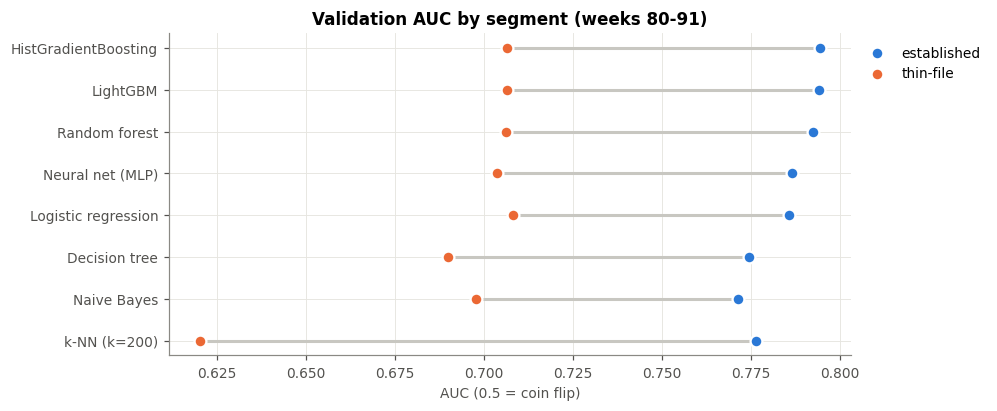

In [6]:
# Dumbbell chart: one row per model, a dot per segment, a line showing the gap between them
order = results.drop("Dummy (base rate)").sort_values("AUC").index     # weakest at the bottom, strongest on top
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(order))
for col, color, label in [("AUC established", C_EST, "established"), ("AUC thin-file", C_THIN, "thin-file")]:
    ax.scatter(results.loc[order, col], y, color=color, s=60, zorder=3, label=label, edgecolor="white", linewidth=1.5)
ax.hlines(y, results.loc[order, "AUC thin-file"], results.loc[order, "AUC established"], color="#c8c7c1", lw=2, zorder=2)
ax.set_yticks(y, order)
ax.set(title="Validation AUC by segment (weeks 80-91)", xlabel="AUC (0.5 = coin flip)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

**What this shows**
- **Boosting wins, but not by much.** LightGBM and HistGradientBoosting lead (AUC ≈ 0.768), followed closely by random forest (≈ 0.766).
  Logistic regression is only ~0.008 behind. The data's signal is mostly simple, roughly straight-line effects, so flexible models have
  little extra to find.
- **The gain is almost all for established applicants.** Boosting lifts established AUC from 0.786 to 0.794, while **thin-file AUC is
  stuck at ≈ 0.69–0.71 for every reasonable model**. Logistic regression is actually (just) the best on thin-file (0.708). No algorithm
  finds more to rank thin-file applicants on, which matches EDA §7: their features are weak, independent signals.
- **Algorithms to drop**: Naive Bayes ranks reasonably, but its probabilities are useless (LogLoss ≈ 3.2, see §6). k-NN is slow to predict and
  much worse on thin-file (≈ 0.62): with no bureau data, "similar applicants" are hard to define. A single decision tree trails the forests.
- **The neural net matches logistic regression** on a quarter of the data. It doesn't beat boosting and is harder to explain to a credit reviewer.

## 5. From probabilities to decisions: profit and the inclusion gap

This is what the challenge actually scores. For each model, apply the baseline policy **approve if PD < 20%** to the validation applicants, then measure:
- **Profit**: +$2,000 per approved loan that's repaid, −$8,000 per approved loan that defaults.
- **Approval rate among repayers**, per segment: of the people who *would* repay, what share does the model approve?
- **Inclusion gap** = established minus thin-file approval rate among repayers (deck slide 15). Smaller is fairer.

In [7]:
def policy(y, p, thin, threshold=THRESHOLD):
    """Apply 'approve if PD < threshold' and summarize profit, approval rates and the inclusion gap."""
    approve = p < threshold
    # Profit only comes from approved loans: +G if repaid, -L if defaulted (denied loans earn and lose nothing)
    profit = G * (approve & (y == 0)).sum() - L * (approve & (y == 1)).sum()
    good = y == 0                                       # applicants who actually repaid
    appr_good_est = approve[good & ~thin].mean()        # share of established repayers we approve
    appr_good_thin = approve[good & thin].mean()        # share of thin-file repayers we approve
    return {"approved %": approve.mean() * 100,
            "approved % (established)": approve[~thin].mean() * 100,
            "approved % (thin-file)": approve[thin].mean() * 100,
            "default rate of approved %": y[approve].mean() * 100 if approve.any() else np.nan,
            "profit ($M)": profit / 1e6,
            "repayers approved % (established)": appr_good_est * 100,
            "repayers approved % (thin-file)": appr_good_thin * 100,
            "inclusion gap (pts)": (appr_good_est - appr_good_thin) * 100}   # deck slide 15: smaller = fairer


# "Approve everyone" = a PD of 0 for all applicants; the Dummy is skipped because it predicts the
# 19.4% training rate for everyone, which is just under 20% and so also approves everyone
approve_all = {"model": "Approve everyone (no model)",
               **policy(y_val, np.zeros_like(y_val, dtype=float), thin_val)}
decisions = pd.DataFrame([approve_all] + [{"model": n, **policy(y_val, p, thin_val)} for n, p in preds.items()
                                          if n != "Dummy (base rate)"]).set_index("model")
decisions.sort_values("profit ($M)", ascending=False).round(2)

,approved %,approved % (established),approved % (thin-file),default rate of approved %,profit ($M),repayers approved % (established),repayers approved % (thin-file),inclusion gap (pts)
model,,,,,,,,
HistGradientBoosting,61.55,71.26,38.80,8.22,94.59,78.26,44.13,34.13
LightGBM,61.67,71.14,39.45,8.26,94.47,78.13,44.80,33.32
Random forest,60.69,70.35,38.02,8.14,93.89,77.34,43.26,34.08
Neural net (MLP),61.19,70.03,40.44,8.37,92.83,76.90,45.68,31.22
Logistic regression,60.52,71.30,35.27,8.32,92.21,78.10,40.32,37.78
Decision tree,62.37,70.05,44.36,8.76,91.41,76.70,49.66,27.04
Naive Bayes,50.75,66.09,14.80,7.42,83.30,72.95,17.47,55.49
k-NN (k=200),53.65,72.53,9.37,8.88,77.80,79.00,10.57,68.42
Approve everyone (no model),100.00,100.00,100.00,17.36,34.49,100.00,100.00,0.00


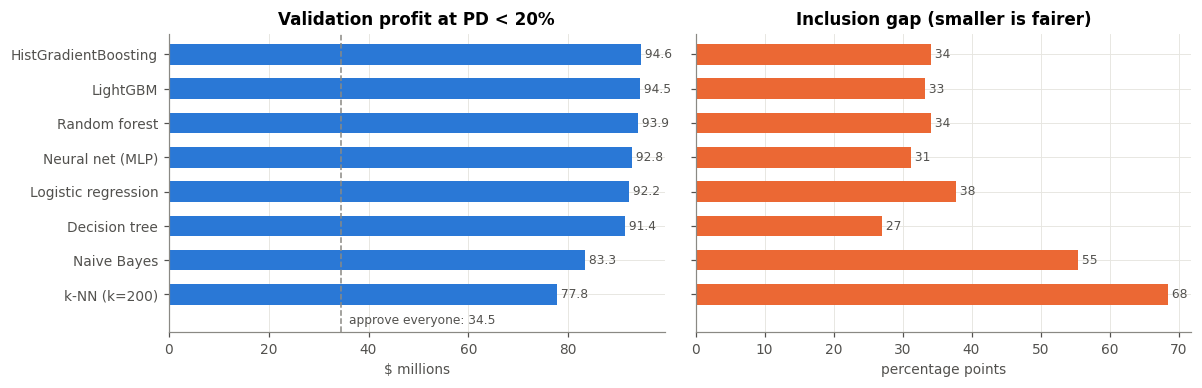

In [8]:
# Left: profit per model against the approve-everyone line. Right: the inclusion gap per model
d = decisions.drop("Approve everyone (no model)").sort_values("profit ($M)")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
y = np.arange(len(d))
axes[0].barh(y, d["profit ($M)"], color=C_EST, height=0.6)
base_profit = decisions.loc["Approve everyone (no model)", "profit ($M)"]
axes[0].axvline(base_profit, color="#8a8984", ls="--", lw=1)
axes[0].annotate(f"approve everyone: {base_profit:.1f}", (base_profit, -0.75), xytext=(5, 0), textcoords="offset points",
                 fontsize=8, color="#52514e", va="center", annotation_clip=False)
axes[0].set_ylim(-1.1, len(d) - 0.4)       # leave room below the bars for the dashed-line label
axes[0].set(title="Validation profit at PD < 20%", xlabel="$ millions")
axes[0].set_yticks(y, d.index)
axes[1].barh(y, d["inclusion gap (pts)"], color=C_THIN, height=0.6)
axes[1].set(title="Inclusion gap (smaller is fairer)", xlabel="percentage points")
# Value labels at the end of every bar
for ax, col, fmt in [(axes[0], "profit ($M)", "{:.1f}"), (axes[1], "inclusion gap (pts)", "{:.0f}")]:
    for yi, v in zip(y, d[col]):
        ax.text(v, yi, " " + fmt.format(v), va="center", fontsize=8, color="#52514e")
plt.tight_layout(); plt.show()

**What this shows**
- Every real model makes far more money than approving everyone, and the ranking by profit roughly follows AUC/LogLoss.
  Boosting earns the most.
- **Every model shows a large inclusion gap: 27–38 points among the usable models.** At the 20% cut-off, about 78% of established
  repayers are approved, but only 40–50% of thin-file repayers. Boosting narrows the gap a little compared with logistic regression
  (33 vs 38 points), and the single tree's smaller gap (27) comes with lower profit. **No algorithm comes close to closing it.**
- The next section shows why.

## 6. Probability quality per segment: where the gap comes from

If the model's probabilities are honest, the **average predicted PD** in a segment should equal that segment's **actual default rate**.

In [9]:
# Average predicted PD vs actual default rate, per segment. Honest probabilities -> the two match.
bias = pd.DataFrame({
    name: {"predicted PD, established": p[~thin_val].mean() * 100, "actual, established": y_val[~thin_val].mean() * 100,
           "predicted PD, thin-file": p[thin_val].mean() * 100, "actual, thin-file": y_val[thin_val].mean() * 100}
    for name, p in preds.items()
}).T
# Positive = the model thinks this segment is riskier than it really is
bias["over-estimate, established (pts)"] = bias["predicted PD, established"] - bias["actual, established"]
bias["over-estimate, thin-file (pts)"] = bias["predicted PD, thin-file"] - bias["actual, thin-file"]
bias.round(1)

,"predicted PD, established","actual, established","predicted PD, thin-file","actual, thin-file","over-estimate, established (pts)","over-estimate, thin-file (pts)"
Dummy (base rate),19.4,16.3,19.4,19.8,3.1,-0.4
Logistic regression,16.3,16.3,26.2,19.8,-0.1,6.4
Naive Bayes,30.9,16.3,84.5,19.8,14.6,64.7
k-NN (k=200),15.6,16.3,27.0,19.8,-0.7,7.2
Decision tree,16.4,16.3,25.3,19.8,0.1,5.5
Random forest,16.5,16.3,25.8,19.8,0.2,6.0
HistGradientBoosting,16.4,16.3,25.6,19.8,0.1,5.8
LightGBM,16.4,16.3,25.5,19.8,0.1,5.7
Neural net (MLP),16.5,16.3,26.5,19.8,0.2,6.7


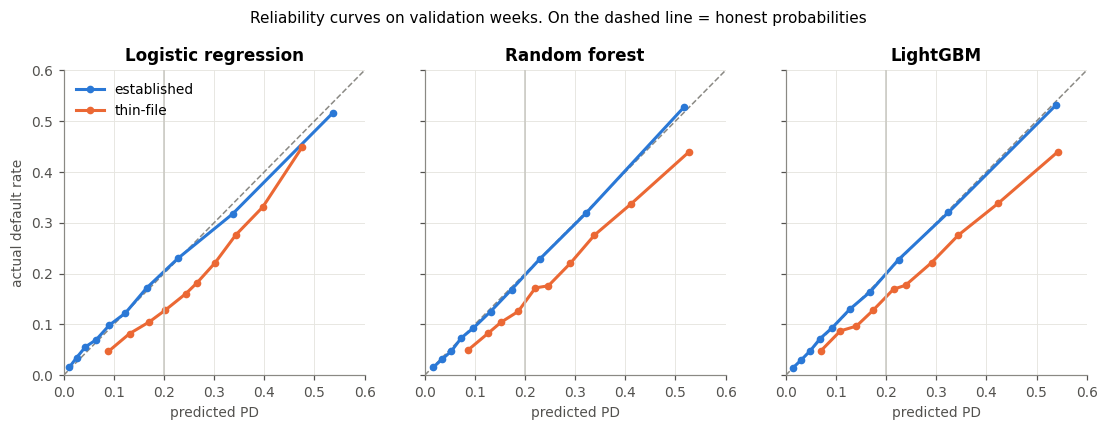

In [10]:
# Reliability curves: bin applicants into deciles of predicted PD, then plot actual default rate per bin
show = ["Logistic regression", "Random forest", "LightGBM"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
for ax, name in zip(axes, show):
    ax.plot([0, 0.6], [0, 0.6], color="#8a8984", ls="--", lw=1)      # perfect calibration
    for mask, color, label in [(~thin_val, C_EST, "established"), (thin_val, C_THIN, "thin-file")]:
        frac, mean_p = calibration_curve(y_val[mask], preds[name][mask], n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, color=color, lw=2, marker="o", ms=4, label=label)
    ax.axvline(THRESHOLD, color="#c8c7c1", lw=1)                     # the 20% approval cut-off
    ax.set(title=name, xlabel="predicted PD", xlim=(0, 0.6), ylim=(0, 0.6))
axes[0].set_ylabel("actual default rate")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Reliability curves on validation weeks. On the dashed line = honest probabilities", fontsize=10, y=1.03)
plt.show()

**This is the key finding of the exploration.**
- For **established** applicants, every good model is well calibrated: predicted ≈ actual, and the blue curve sits on the diagonal.
- For **thin-file** applicants, **every model over-estimates risk by about 6 points** (predicts ~25–26%, actual ~20%). The orange
  curve sits **below** the diagonal. That's exactly what the feature catalog's step 1 says to look for.
- The cause isn't the algorithm. It's the **drift** found in EDA (notebook 01b §4): models learn the thin-file default rate from weeks 0–79,
  averaging ~26.5%, but by weeks 80–91 the true rate has fallen to ~20%.
- Because the rule is "approve if PD < 20%", that ~6-point upward bias pushes many good thin-file applicants over the line. **That is the inclusion gap.**
- (Naive Bayes is the extreme case: its independence assumption pushes probabilities to 0 or 1, so its average thin-file PD is ~85%.)

## 7. Conclusions and hand-off to Issue #12

| | Verdict | Reason |
|---|---|---|
| **LightGBM** | ✅ **Shortlist (primary)** | Joint-best AUC, LogLoss and profit (tied with HistGradientBoosting); ~3 s to train; native missing values; the deck's recommended workhorse; the most tuning headroom for #14 |
| **Logistic regression** | ✅ **Shortlist (baseline)** | Required baseline to beat; only ~0.008 AUC behind; fully interpretable; same thin-file AUC as boosting |
| **Random forest** | ✅ Shortlist (comparison) | Close third; the deck's "non-linear" model; ~13× slower to train than LightGBM |
| HistGradientBoosting | ➖ Optional | Ties LightGBM; redundant with it, so keep one boosting library |
| Neural net (MLP) | ❌ Drop | No gain over logistic regression; harder to explain |
| Decision tree | ❌ Drop | Beaten by both forests; useful only as an explainer |
| k-NN | ❌ Drop | Weakest on thin-file (≈ 0.62 AUC); slow predictions |
| Naive Bayes | ❌ Drop | Probabilities unusable (LogLoss ≈ 3.2) |

This matches the deck's three-model plan (logistic regression → random forest → gradient boosting), now backed by evidence from our data.

**Main lessons for the next issues**
1. **Algorithm choice is a small lever** (≈ +0.008 AUC, all for established applicants). Don't spend most of #13/#14 hunting for a better algorithm.
2. **The inclusion gap is a calibration problem**: every model over-predicts thin-file PD by ~6 points on later weeks. The biggest wins should
   come from **per-segment calibration fitted on the most recent weeks**, **recency weighting**, and a **segment-aware threshold**, not from model choice.
3. **Always report metrics per segment.** Overall AUC hides that thin-file performance barely moves.
4. **For #14 (tuning):** tune LightGBM with early stopping on a validation fold of the latest fit weeks, and check thin-file LogLoss, not just overall AUC.